# Visualisation of Pareto Fronts, System Functionality and Water Loss for the Multi-Objective Optimisation of the Number of Repair Crews in the BPDRR

This notebook generates the visual representations (Pareto fronts and time series) of the results produced by the `MOO_BPDRR_NRC.ipynb` notebook.

The optimisation results are provided as two CSV files:

- **`pareto_OF_x.csv`**: contains the values of the objective functions for each solution obtained from the multi-objective optimisation process.
- **`pareto_solutions_x.csv`**: contains the repair order of the damaged pipes associated with each solution obtained from the multi-objective optimisation process.

This notebook requires three Python files specific to this research, which are used as modules:

- **`OF_BPDRR.py`**: Contains the functions used to calculate the objective functions from the BPDRR.
- **`RC_scheduling.py`**: Contains the functions used to estimate the allocation and scheduling of the repair crews.
- **`visuals_BPDRR.py`**: Contains the functions used to generate the Pareto fronts and time-series plots.

Please make sure that these modules are available in the appropriate directory and are imported correctly before running the notebook.

In [973]:
# Import libraries to be used
import os
import wntr
import pandas as pd
import numpy as np
from pymoo.util.nds.non_dominated_sorting import NonDominatedSorting

# Specialized libraries for this project
import OF_BPDRR as OF
import RC_scheduling as rcs
import visuals_BPDRR as visuals

### Selection of the scenario, specific solution, and number of crews

The cell below allows the user to select the following:

- **`ds_sel`**: Select one of the five damage scenarios to analyse (`DS1`, `DS2`, `DS3`, `DS4`, or `DS5`).
- **`n_crews`**: Specify the number of repair crews used in the optimisation process. This variable is used for labelling the plots.
- **`gen_sel`**: Select the generation to which the solution being plotted belongs.
- **`sol_sel`**: Select one of the solutions obtained from the multi-objective optimisation process. This is required to generate the functionality and water-loss time series.


In [974]:
# which damage scenario to analyse
ds_sel = 'DS4'  # Replace with the desired damage scenario (DS1, DS2, DS3, DS4, DS5)

# Number of crews available for the restoration simulation
n_crews = 60

# Generation to which the selected solution belongs
gen_sel = 80

# Select the solution to plot (0 to the number of solutions in the selected generation)
sol_sel = 44  # Replace with the index of the desired solution



In [975]:
# Dictionary to store information for the plot title
plot_info = {
    "scenario": ds_sel,
    "solution": sol_sel,
    "generation": gen_sel,
    "crews": n_crews
}

In [976]:
# load the wdn as INP file WITH the broken pipes
inp_file = "BBM-EPS_"+ds_sel+"mcg.inp"

# Define the temporary INP file used for the restoration simulation
temp_inp="temp_restoration_"+ds_sel+".inp"

# Load the water network model from the INP file
wn = wntr.network.WaterNetworkModel(inp_file)

In [977]:
# Simulation settings
wn.options.time.duration = 3*24 * 3600       # Time duration of the WNTR simulation
wn.options.time.hydraulic_timestep = 15 * 60     # 15 minutes
wn.options.time.report_timestep = 15 * 60        # 15 minutes

# Start simulation at 07:00 AM
wn.options.time.start_clocktime = 7 * 3600

# Pressure Driven Analysis
wn.options.hydraulic.demand_model = "PDA"
wn.options.hydraulic.required_pressure = 20
wn.options.hydraulic.minimum_pressure = 0
wn.options.hydraulic.pressure_exponent = 0.5

In [978]:
# timestep
dt = wn.options.time.hydraulic_timestep

# timestep in minutes
dtm = dt/60

In [979]:
# Read the data from the excel file that contains the repair times for the selected damage scenario
df = pd.read_excel(
    "DS_with_full_description.xlsx",
    sheet_name= ds_sel
)

# Repair time discretization (hours)
repair_time_interval = 0.25  # 15 minutes

# Build the reparations dictionary
time_reparation = {}

for _, row in df.iterrows():

    repair_time = float(row["fix time (hours)"])

    # Round up to the nearest interval
    repair_time = np.ceil(repair_time / repair_time_interval) * repair_time_interval

    time_reparation[str(row["Pipe ID"])] = {
        "t_r": repair_time
    }

print(f"{len(time_reparation)} repairs loaded.")

121 repairs loaded.


In [980]:
# Find all demand nodes (base demand > 0)
demand_nodes = []

# Expected demand at each node

for node_name in wn.junction_name_list:

    node = wn.get_node(node_name)

    if node.base_demand > 0:

        demand_nodes.append(node_name)

print(f"Demand nodes found: {len(demand_nodes)}")

Demand nodes found: 4201


In [981]:
# Finding emitter nodes (nodes starting with "E_")
emitter_nodes = [
    j for j in wn.junction_name_list
    if j.startswith("E_")
]

In [982]:
# Expected demand
expected = wntr.metrics.expected_demand(wn)

expected *= 1000        # convert to L/s

expected = expected[demand_nodes]

expected.index = expected.index.astype(int)


In [983]:
# Pipe IDs from the reparations dictionary
pipe_ids = list(time_reparation.keys())

In [984]:
# Import the travel time matrix from the parquet file
dmatrix_df = pd.read_parquet(
    "TravelTime_"+ds_sel+".parquet"
)

# Standardise IDs so the repair dictionary and matrix use the same keys
dmatrix_df.index = dmatrix_df.index.map(str)
dmatrix_df.columns = dmatrix_df.columns.map(str)


In [985]:
# The scenario dictionary contains all the information required to run the optimisation process
scenario = {

    # Restoration
    "damaged_inp": inp_file,
    "reparations": time_reparation,
    "dmatrix": dmatrix_df,
    "pipe_ids": pipe_ids,
    "n_crews": n_crews,
    "temp_inp": temp_inp,

    # Hydraulic data
    "demand_nodes": demand_nodes,
    "emitter_nodes": emitter_nodes,
    "expected": expected,

    # Time
    "dt": dt,
    "dtm": dtm,

    # Simulation settings
    "duration": wn.options.time.duration,
    "hydraulic_timestep": wn.options.time.hydraulic_timestep,
    "report_timestep": wn.options.time.report_timestep,

    "demand_model": wn.options.hydraulic.demand_model,
    "required_pressure": wn.options.hydraulic.required_pressure,
    "minimum_pressure": wn.options.hydraulic.minimum_pressure,
    "pressure_exponent": wn.options.hydraulic.pressure_exponent,

    # Objective constants
    "service_ratio": 0.5,
    "consecutive_hours": 8,
    
}

In [986]:
# Read the data from the CSV file containing the objective function values for the selected damage scenario MOO
data = pd.read_csv(
    f"pareto_OF_history_{ds_sel}_{n_crews}RC.csv",
    index_col=["Generation", "Solution"]
)

data[-126:]

FH     t95           RL        TNS  NWSECH  \
Generation Solution                                                  
80         0         435.0  1260.0  5161.278570  28.107593    62.0   
           1         285.0  1260.0  5236.532103  22.419662    55.0   
           2         510.0  1260.0  4397.046546  26.579386   121.0   
           3         630.0  1200.0  4465.042807  24.929779    87.0   
           4         525.0  1260.0  4531.061222  22.915972    48.0   
...                    ...     ...          ...        ...     ...   
           121       300.0  1260.0  5331.556752  22.723161    60.0   
           122       690.0  1260.0  5778.926649  23.755058    95.0   
           123       510.0  1260.0  4623.798863  23.615806    56.0   
           124       285.0  1260.0  5334.542642  22.994525    55.0   
           125       555.0  1260.0  4647.491824  26.772197   108.0   

                              WL  
Generation Solution               
80         0         4474.210449  
           1         4408.333008  
           2         5007.273926  
           3         3820.404297  
           4         4747.495117  
...                          ...  
           121       4365.703125  
           122       3950.311035  
           123       4863.206055  
           124       4302.353516  
           125       4269.241699  

[126 rows x 6 columns]

In [987]:
# Read the data from the CSV file containing the repair orders
pareto_solutions = pd.read_csv(
    f"pareto_solutions_history_{ds_sel}_{n_crews}RC.csv",
    index_col=["Generation", "Solution"]
)

pareto_solutions

0   1    2    3    4    5    6    7    8   9  ...  111  \
Generation Solution                                                 ...        
1          0         23  58   30   35   84   64   45  108   86  34  ...   16   
           1         82  93  104   23   96   26   24   97  116  83  ...   48   
           2         17  62   54    1   68   81  111   38   40  96  ...  115   
           3         83   6   94  100   65   66   14    3    0   1  ...   21   
           4         64   8   93   98   33   68    1   42   92  15  ...   60   
...                  ..  ..  ...  ...  ...  ...  ...  ...  ...  ..  ...  ...   
80         121        1  71   43  117    7   45    3   74   27  80  ...  107   
           122        1  27  110    8   64   49   59   43   84  74  ...  103   
           123        1   3   66   26  112   82   62   10   53  15  ...    0   
           124        1  43   78   53   69   74    3   32    2  36  ...   94   
           125        1  46    3   27   24  110   51   45    7  63  ...   25   

                     112  113  114  115  116  117  118  119  120  
Generation Solution                                               
1          0          14   57   36   71   54    5  117   19  120  
           1          35   10   70   69    9   57   77   73   56  
           2           8   50   73   56   85   95   84   46   10  
           3          15   73   61   12   55   97  110   31   34  
           4          80   44    9   95   59   70   77   35   27  
...                  ...  ...  ...  ...  ...  ...  ...  ...  ...  
80         121        60   97  104   86   38   25   59    9   47  
           122        78   38   97   71   95   54   26  120  115  
           123        95   86   39   59  115   25   44   52   46  
           124        70   40   60   11   47   97   95  101   59  
           125        49   88   91   98  103   71  115   97   59  

[10080 rows x 121 columns]

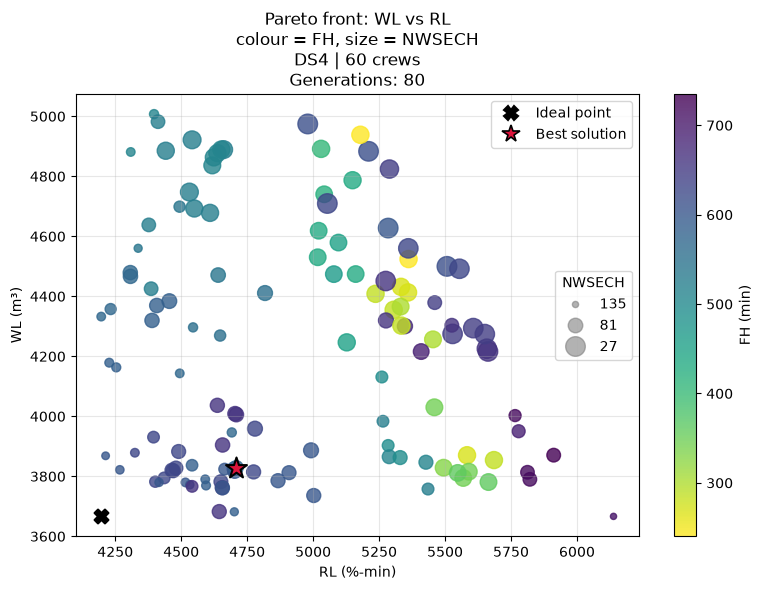

(<Figure size 800x600 with 2 Axes>,
 <Axes: title={'center': 'Pareto front: WL vs RL\ncolour = FH, size = NWSECH\nDS4 | 60 crews\nGenerations: 80'}, xlabel='RL (%-min)', ylabel='WL (m³)'>)

In [988]:
# Pareto front plot using four objective functions
# Names of the objective functions to choose: FH, t95, RL, TNS, NWSECH, WL
# Generations: Choose the generations to plot e.g. last three gennerations= [48, 49, 50])
obj1="RL"
obj2="WL"

visuals.plot_pareto_OF_MG(
    data=data,
    obj1=obj1,
    obj2=obj2,
    color_obj="FH",
    size_obj="NWSECH",
    plot_info=plot_info,
    generations=[gen_sel],
#    pareto_objectives=[obj1, obj2]
)

In [989]:
# Filter Pareto solutions by objective-function ranges
pareto_generation = data.loc[gen_sel].copy()

# Define the objective-function ranges (edit according to your selected objectives and the solutions you want to find)
obj1_min = 5000  
obj1_max = 5300

obj2_min = 22500
obj2_max = 22700

# Filter the Pareto front
selected_solutions = pareto_generation[
    pareto_generation[obj1].between(obj1_min, obj1_max)
    &
    pareto_generation[obj2].between(obj2_min, obj2_max)
]

# Display the selected solutions
print(
    f"Found {len(selected_solutions)}"
    f" solutions within the specified ranges:"
)

selected_solutions

Found 0 solutions within the specified ranges:


,FH,t95,RL,TNS,NWSECH,WL
Solution,,,,,,


In [990]:
# Identify the best compromise solution

best_id, best_OF, best_distance = visuals.best_solution(
    data,
    generations=[gen_sel]
)

print(f"Best solution: Generation {best_id[0]}, Solution {best_id[1]}")
print(f"Normalised euclidean distance to ideal point: {best_distance:.3f}")

best_OF

Best solution: Generation 80, Solution 112
Normalised euclidean distance to ideal point: 1.026


FH         570.000000
t95       1200.000000
RL        4708.538158
TNS         25.411807
NWSECH      86.000000
WL        3828.925781
Name: (80, 112), dtype: float64

### Time Series Section

This section of the notebook is used to generate the functionality and water-loss time series for the selected solution.

Because these time series require the hydraulic results for each timestep throughout the simulation period, it is necessary to run a restoration simulation using the repair order associated with the selected solution. The simulation results are then used to calculate the functionality and water-loss time series, as well as the corresponding objective values, such as the time to 95% recovery (t95), resilience loss (RL), and water loss (WL).

In [991]:
# Function to simulate the restoration process
def simulate_restoration(
    indexes,
    scenario,
    save_temp_inp=False,
):
    """
    Run one hydraulic restoration simulation.

    Parameters
    ----------
    indexes : list
        Permutation of damaged pipes (decision variable).

    scenario : dict
        Dictionary containing all fixed information for the
        restoration scenario.

    temp_inp : str
        Temporary INP file used during the simulation.

    save_temp_inp : bool, optional
        If True, the temporary INP is kept after the simulation.
        Otherwise it is deleted.

    Returns
    -------
    simulation : dict

        {
            "results" : SimulationResults,
            "schedule": pandas.DataFrame,
            "network" : WaterNetworkModel
        }
    """

    # Create repair schedule

    schedule = rcs.create_schedule(

        reparations=scenario["reparations"],

        dmatrix=scenario["dmatrix"],

        pipe_ids=scenario["pipe_ids"],

        indexes=indexes,

        n_crews=scenario["n_crews"],

    )

    # Generate EPANET controls

    controls = rcs.generate_controls(
        schedule
    )

    # Create temporary INP

    rcs.write_inp_controls(

        input_inp=scenario["damaged_inp"],

        output_inp=scenario["temp_inp"],

        schedule=schedule,

        new_controls=controls,

    )

    # Load temporary network

    wn = wntr.network.WaterNetworkModel(scenario["temp_inp"])

    wn.options.time.duration = scenario["duration"]
    wn.options.time.hydraulic_timestep = scenario["hydraulic_timestep"]
    wn.options.time.report_timestep = scenario["report_timestep"]
    wn.options.hydraulic.demand_model = scenario["demand_model"]
    wn.options.hydraulic.required_pressure = scenario["required_pressure"]
    wn.options.hydraulic.minimum_pressure = scenario["minimum_pressure"]
    wn.options.hydraulic.pressure_exponent = scenario["pressure_exponent"]
   
    # Run hydraulic simulation
    
    sim = wntr.sim.EpanetSimulator(wn)

    results = sim.run_sim()

    # Remove temporary INP

    if not save_temp_inp:

        try:
            os.remove(scenario["temp_inp"])

        except FileNotFoundError:
            pass

    # Return simulation

    simulation = {

        "results": results,

        "schedule": schedule,

        "network": wn,

    }

    return simulation

In [992]:
# Order of the pipe's indexes from the selected solution 
indexes = pareto_solutions.loc[
    (gen_sel, sol_sel)
].to_numpy(dtype=int)

#print("Generation:", gen_sel)
print("Solution:", sol_sel)
print("Indexes:")
print(indexes)

Solution: 44
Indexes:
[  2   1  46 110  51   3  27  24   4  29   8  84  36  66  53  52  32 101 114   7  45   6  48  69  42  58  26  43  19  30  62 113  73  81  37  15  86  87  75  71  41 105  35  78  63  23  99  67  47 115  13 118   0   5  64  59  95  10  16  33 100  68 107  12  61  40 112  80  14 109  28  21  34  85
 119  57 102  65 108  79  17  92  96   9  72 106  56  77  76  22 116  93  31  70  91  20  82  83  50  89 120  54  44  18  60  11  39 111  94  38 104  97  98  55 117  49  88 103  90  25  74]


In [993]:
# Run one restoration simulation
simulation = simulate_restoration(
    indexes=indexes,
    scenario=scenario,
#    temp_inp=temp_inp,
    save_temp_inp=False
)

# Extract simulation results
results = simulation["results"]

demand = results.node["demand"] * 1000  # convert to L/s

pressure = results.node["pressure"]

flowrate = results.link["flowrate"]


# Supply ratio
supply_ratio = (
    demand[scenario["demand_nodes"]]
    / scenario["expected"]
)

# Objective 1 - Time without supply for hospital/firefighting (FH)
FH, FH_undersupplied = OF.OF_FH(
    supply_ratio=supply_ratio,
    dtm=scenario["dtm"]
)

# Objective 2 - Rapidity of recovery (t95)
t95 = OF.OF_t95(
    demand=demand,
    demand_nodes=scenario["demand_nodes"],
    expected=scenario["expected"],
    dtm=scenario["dtm"]
)

# Objective 3 - Resilience loss (RL)
RL = OF.OF_RL(
    demand=demand,
    demand_nodes=scenario["demand_nodes"],
    expected=scenario["expected"],
    dtm=scenario["dtm"]
)

# Objective 4 - Average time of no user service (TNS)
TNS = OF.OF_time_no_serv(
    supply_ratio=supply_ratio,
    dtm=scenario["dtm"],
    ratio=scenario["service_ratio"]
)

# Objective 5 - Number of users without service for eight consecutive hours (NWSECH)
NWSECH = OF.OF_NWSECH(
    supply_ratio=supply_ratio,
    dtm=scenario["dtm"],
    ratio=scenario["service_ratio"],
    hours=scenario["consecutive_hours"]
)

# Objective 6 - Water loss (WL)
WL = OF.OF_WL(
    demand=demand,
    emitter_nodes=scenario["emitter_nodes"],
    dt=scenario["dt"]
)

# Print results
print(f"FH      = {FH:.2f}")
print(f"t95     = {t95:.2f}")
print(f"RL      = {RL:.2f}")
print(f"TNS     = {TNS:.2f}")
print(f"NWSECH  = {NWSECH}")
print(f"WL      = {WL:.2f}")

FH      = 630.00
t95     = 1200.00
RL      = 4435.53
TNS     = 26.05
NWSECH  = 105
WL      = 3794.65


In [994]:
functionality_series = OF.system_functionality(demand, demand_nodes, expected)

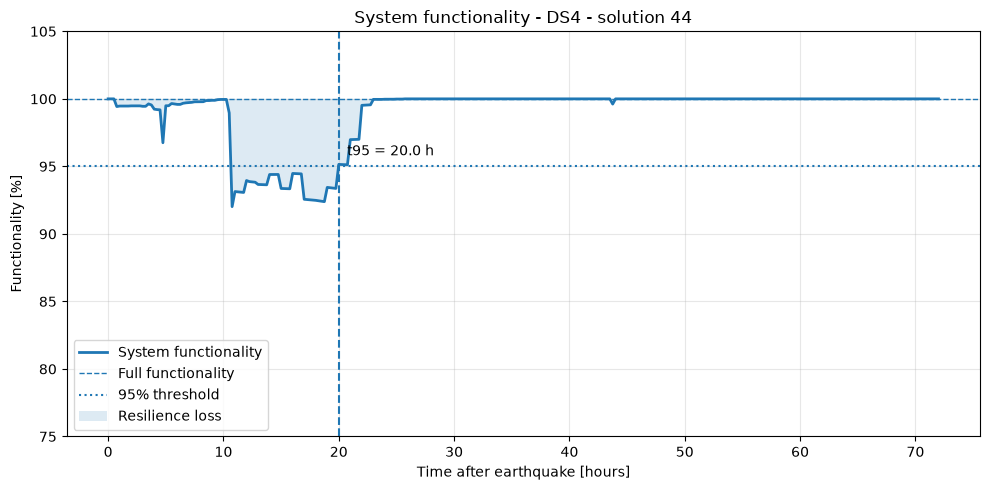

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'System functionality - DS4 - solution 44'}, xlabel='Time after earthquake [hours]', ylabel='Functionality [%]'>)

In [995]:
visuals.plot_functionality(
    functionality_series=functionality_series,
    t95=t95,
    scenario_name=ds_sel,
    sol_sel=sol_sel
)

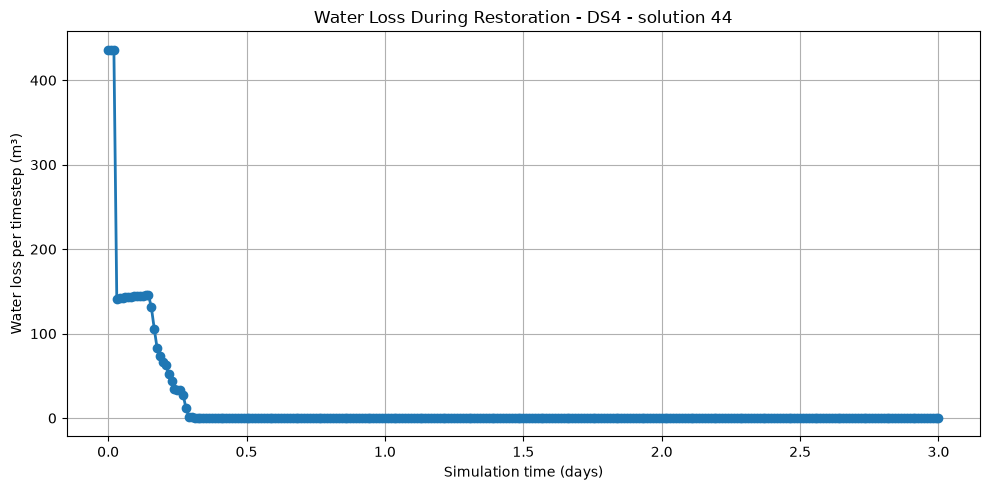

(<Figure size 1000x500 with 1 Axes>,
 <Axes: title={'center': 'Water Loss During Restoration - DS4 - solution 44'}, xlabel='Simulation time (days)', ylabel='Water loss per timestep (m³)'>)

In [996]:
visuals.plot_water_loss(
    demand=demand,
    emitter_nodes=scenario["emitter_nodes"],
    dt=scenario["dt"],
    scenario_name=ds_sel,
    sol_sel=sol_sel
)